# Script Description

This is an EEG (Electroencephalography) data processing script that performs several important preprocessing steps:
- Initial Setup:
    - Sets up a standard EEG montage (electrode layout) using the 'easycap-M1' configuration
    - Modifies one channel name (FP2)
    - Defines paths for reading EEG data files
    - Data Loading and Initial Processing (for participants 1-35, excluding participant 18):
    - Loads raw EEG data from BrainVision format files
- Applies two types of filtering:
    - Band-pass filtering (0.1-30.0 Hz) to remove very low and high frequencies
    - Notch filtering at 60 Hz to remove power line interference
    - Sets the montage for the EEG data
    - Loads corresponding event data from MATLAB files
- ICA (Independent Component Analysis) Cleaning:
    - Performs automatic ICA cleaning with the following parameters:
    - Uses 32 components
    - Maximum 1000 iterations
    - Uses the "infomax" method
    - Sets a confidence cutoff of 0.90 for component classification
- For each participant:
    - Applies average reference
    - Fits ICA to the filtered data
    - Uses ICLabel to automatically classify components
    - Removes components that are not classified as 'brain' or 'other' with high confidence
    - Tracks which components were removed for each participant
- Final Processing and Storage:
    - Creates a dictionary of cleaned EEG data
    - Excludes participants with bad data (IDs 4, 5, 6, 9, 15, 18, 23, 33)
    - Saves the cleaned data to a pickle file
- Segmentation of EEG data into epochs:
    - Gets the sampling frequency from the EEG data
    - Defines event IDs for four different conditions
    - Defines epoch time window (-0.1s to 0.4s relative to event onset)
- Event Processing (for participants 1-35, excluding bad data participants):
    - Extracts event timings for all four conditions from the loaded data
    - Creates time frames for each condition with corresponding event markers
    - Combines and sorts all events chronologically
    - Converts trigger codes to sample points
    - Creates an events array with trigger samples and condition labels
- Epoch Creation:
    - Uses the cleaned ICA data from the previous step
    - Applies baseline correction (-0.1s to 0s)
    - No rejection criteria applied
    - Preloads the data
    - Separates epochs into four condition-specific lists
- Data Organization and Storage:
    - Creates a dictionary containing lists of epochs for each condition
    - Saves the cleaned data to a pickle file

Notes:
- Raw data is saved as .vhdr and annotations as .mat
- Participant 18 does not exist in the dataset
- Channel names for frontal are FP1 and Fp2, I changed Fp2 to FP2.

# Preprocessing

## Imports

In [1]:
# Preprocessing section
import mne
import mne_icalabel
from mne.preprocessing import ICA

import numpy as np
import pickle
from scipy.io import loadmat
from pathlib import Path
import os
import matplotlib.pyplot as plt

set directory workspace for your computer (usually needs only to be executed once)

In [ ]:
os.chdir(r"C:/Users/VTDEK/OneDrive - Université Laval/Documents/code")

## File Parameters

In [6]:
#Setup
montage = mne.channels.make_standard_montage('easycap-M1')
montage.ch_names[1]='FP2' # There is a mistake in the raw annotation, had to change to upper case to solve it here.
Random_Seed_State = 91
File_Type = '.vhdr' #Raw data is saved as .vhdr and annotation as .mat


Number_of_Participants = 1
Number_of_Participants += 1 # it will remain n participants, just edit for the loop
base_path = Path(r'//ul.ca/CSTIP/Recherche/COGITE/Projets/CRSNG_Neurophysio Émotions et Cognition/2024__Trauma_Analogue_EEG_ML_Damiem/4. Données et Analyses (DATA)/EEG/Preprocessed_EEG')
data_path_store = Path("..") / "data"

## Band Pass Filter & Automatic ICA removal

In [ ]:
# for each participants band pass filter. participant 18 does not exist in the dataset
print('----------------------------------------------Filtering Data------------------------------------------------------------') 

for ID in range(1, Number_of_Participants):
    if ID == 18:
        continue

    participant_filename = 'participant'+ str(ID) + File_Type
    print(participant_filename)
    participant_filepath = base_path / '0_Raw_EEG' / participant_filename
    vars()["RawEEG_Participant"+str(ID)] = mne.io.read_raw_brainvision(participant_filepath, preload=True)
    Band_Filtered_EEG=vars()["RawEEG_Participant"+str(ID)].copy().filter(l_freq=0.1, h_freq=30.0)
    vars()["Notch_Band_Filtered_EEG_Participant"+str(ID)] = Band_Filtered_EEG.copy().notch_filter(freqs=60.0)
    vars()["Notch_Band_Filtered_EEG_Participant"+str(ID)].set_montage(montage)

    if ID < 10:
        mat_file_path = base_path / '0_Raw_EEG' / f'events_data_block00{ID}.mat'
        vars()["Participant"+str(ID)+'_Data'] = loadmat(mat_file_path)
    else: 
        mat_file_path = base_path / '0_Raw_EEG' / f'events_data_block0{ID}.mat'
        vars()["Participant"+str(ID)+'_Data'] = loadmat(mat_file_path)


# Create dictionary with each participant's Band passed Data 
dict_Band_Passed_EEG = {}

for ID in range(1,Number_of_Participants):

    #remove those with Bad data from ICA
    if ID in [4,5,6,9,15,18,23,33]:
        continue
    
    dict_Band_Passed_EEG['Notch_Band_Filtered_EEG_Participant'+str(ID)]=vars()["Notch_Band_Filtered_EEG_Participant"+str(ID)]
# with open(Path+'dict_Band_Passed_EEG.p', 'wb') as fp:
#     pickle.dump(dict_Band_Passed_EEG, fp, protocol=pickle.HIGHEST_PROTOCOL)

print('----------------------------------------------Automatic ICA------------------------------------------------------------') 
Confidence_cutoff = 0.90
Participants_ICA_Removed = []
for ID in range(1,Number_of_Participants):
    if ID == 18:
        continue

    print('--------------------------------')
    print(f"Cleaning Participant: {ID}")
    ica = ICA(n_components=32,max_iter=1000,method="infomax",random_state=Random_Seed_State,fit_params=dict(extended=True))
    filt_raw = vars()["Notch_Band_Filtered_EEG_Participant"+str(ID)].copy().set_eeg_reference("average")
    ica.fit(filt_raw)
    ic_labels =mne_icalabel.label_components(filt_raw,ica,method="iclabel")
    Removal_Location=[]
    for location in (np.where(ic_labels['y_pred_proba']>Confidence_cutoff)[0]):
        if ic_labels['labels'][location] == 'brain' or ic_labels['labels'][location]=='other':
            pass
        else:
            # print(ic_labels['labels'][location],np.round(ic_labels['y_pred_proba'][location],3))
            Removal_Location.append(location)
    Participants_ICA_Removed.append(Removal_Location)
    vars()["Notch_Band_Filtered_EEG_ICA_Participant"+str(ID)]=vars()["Notch_Band_Filtered_EEG_Participant"+str(ID)].copy()
    ica.apply(vars()["Notch_Band_Filtered_EEG_ICA_Participant"+str(ID)],exclude=Removal_Location)
    # Graph=vars()["Notch_Band_Filtered_EEG_ICA_Participant"+str(ID)].plot(n_channels=58, show_scrollbars=False)
    print(f"Participant {ID} got {len(Removal_Location)} component(s) removed")
    del vars()["Notch_Band_Filtered_EEG_Participant"+str(ID)],Removal_Location,filt_raw,ica,ic_labels
    
# Create dictionary with each participant's Final Cleaned Data 
dict_Clean_ICA_EEG = {}
for ID in range(1,Number_of_Participants):
    #remove those with Bad data from ICA
    if ID not in [4,5,6,9,15,18,23,33]:
        dict_Clean_ICA_EEG['Notch_Band_Filtered_EEG_ICA_Participant'+str(ID)]=vars()["Notch_Band_Filtered_EEG_ICA_Participant"+str(ID)]
# with open('dict_Clean_ICA_EEG.p', 'wb') as fp:
#     pickle.dump(dict_Clean_ICA_EEG, fp, protocol=pickle.HIGHEST_PROTOCOL)

----------------------------------------------Filtering Data------------------------------------------------------------
participant1.vhdr
Extracting parameters from \\ul.ca\CSTIP\Recherche\COGITE\Projets\CRSNG_Neurophysio Émotions et Cognition\2024__Trauma_Analogue_EEG_ML_Damiem\4. Données et Analyses (DATA)\EEG\Preprocessed_EEG\0_Raw_EEG\participant1.vhdr...
Setting channel info structure...
Reading 0 ... 1596349  =      0.000 ...  3192.698 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 16501 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done  60 out of  60 | elapsed:    4.9s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3301 samples (6.602 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  60 out of  60 | elapsed:    3.0s finished


----------------------------------------------Automatic ICA------------------------------------------------------------
--------------------------------
Cleaning Participant: 1
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 60 channels (please be patient, this may take a while)
Selecting by number: 32 components
Computing Extended Infomax ICA
Fitting ICA took 638.7s.


C:\Users\VTDEK\AppData\Local\Temp\ipykernel_7428\2765155100.py:49: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels =mne_icalabel.label_components(filt_raw,ica,method="iclabel")


Applying ICA to Raw instance
    Transforming to ICA space (32 components)
    Zeroing out 2 ICA components
    Projecting back using 60 PCA components
Participant 1 got 2 component(s) removed


## Epoching

In [8]:
sfreq = vars()["RawEEG_Participant1"].info['sfreq'] # the value is 500.0
eventIDs = {'Condition 1':1, 'Condition 2':2, 'Condition 3':3, 'Condition 4':4}
Reject_criteria = dict(eeg=100e-6) #time window rejection for variation of 100 uv can add more info: mag=3000e-15,grad=3000e-13,CURRENTLY NOT USING

#Creating a variable for EVENTS structure
epochStart= -.1 # Start of the Window size
epochEnd=0.4 # End of the Window size
Condition1Epochs_list = []
Condition2Epochs_list = []
Condition3Epochs_list = []
Condition4Epochs_list = []

for ID in range(1,Number_of_Participants):
    #remove those with Bad data from ICA
    if ID in [4,5,6,9,15,18,23,33]: # in the data set there were individuals that had bad signals, I concluded this with the ICA and looking at the full EEGs
        print(f"Participant {ID} has bad data, skipping...")
        continue
    
    # Getting the trigger location and label and ordering them
    vars()["Participant"+str(ID)+'_Time_of_Event_Condition1']=vars()["Participant"+str(ID)+'_Data']['events'][0][1][3]
    vars()["Participant"+str(ID)+'_Time_of_Event_Condition2']=vars()["Participant"+str(ID)+'_Data']['events'][0][2][3]
    vars()["Participant"+str(ID)+'_Time_of_Event_Condition3']=vars()["Participant"+str(ID)+'_Data']['events'][0][3][3]
    vars()["Participant"+str(ID)+'_Time_of_Event_Condition4']=vars()["Participant"+str(ID)+'_Data']['events'][0][4][3]
    vars()["Participant"+str(ID)+'_Condition1_TimeFrame']=np.c_[vars()["Participant"+str(ID)+'_Time_of_Event_Condition1'][0],np.ones(len(vars()["Participant"+str(ID)+'_Time_of_Event_Condition1'][0]))*1]
    vars()["Participant"+str(ID)+'_Condition2_TimeFrame']=np.c_[vars()["Participant"+str(ID)+'_Time_of_Event_Condition2'][0],np.ones(len(vars()["Participant"+str(ID)+'_Time_of_Event_Condition2'][0]))*2]
    vars()["Participant"+str(ID)+'_Condition3_TimeFrame']=np.c_[vars()["Participant"+str(ID)+'_Time_of_Event_Condition3'][0],np.ones(len(vars()["Participant"+str(ID)+'_Time_of_Event_Condition3'][0]))*3]
    vars()["Participant"+str(ID)+'_Condition4_TimeFrame']=np.c_[vars()["Participant"+str(ID)+'_Time_of_Event_Condition4'][0],np.ones(len(vars()["Participant"+str(ID)+'_Time_of_Event_Condition4'][0]))*4]
    Time_of_Events_per_Condition_Unordered= np.reshape(np.array((vars()["Participant"+str(ID)+'_Condition1_TimeFrame'],vars()["Participant"+str(ID)+'_Condition2_TimeFrame'],vars()["Participant"+str(ID)+'_Condition3_TimeFrame'],vars()["Participant"+str(ID)+'_Condition4_TimeFrame'])),(4*len(vars()["Participant"+str(ID)+'_Condition1_TimeFrame']),2))
    vars()["Participant"+str(ID)+'_Time_of_Events_per_Condition']=Time_of_Events_per_Condition_Unordered[Time_of_Events_per_Condition_Unordered[:, 0].argsort()]
    # Loading trigger codes from data
    triggerCodes = vars()["Participant"+str(ID)+'_Time_of_Events_per_Condition'][:,0]
    # Converting trigger codes to trigger samples
    triggerSamples = (triggerCodes * sfreq ).astype(int)
    # Extracting condition labels
    conditionLabels = (vars()["Participant"+str(ID)+'_Time_of_Events_per_Condition'][:,1]).astype(int)
    # Creating EEG events array with trigger samples and condition labels
    vars()["Participant"+str(ID)+'_EEGEvents'] = np.column_stack((triggerSamples, np.zeros_like(triggerSamples), conditionLabels))


    # Using MNE function to Epoch data 
    conditionEpochs = mne.Epochs(dict_Clean_ICA_EEG['Notch_Band_Filtered_EEG_ICA_Participant'+str(ID)],
                                    events= vars()["Participant"+str(ID)+'_EEGEvents'],
                                    event_id=eventIDs,
                                    tmin=epochStart,
                                    tmax=epochEnd,
                                    baseline=(-0.1, 0),
                                    # reject_tmin = 0, # used for removing variation within a time window.
                                    # reject_tmax = 0.2,
                                    # reject=Reject_criteria,
                                    reject_by_annotation = False,
                                    preload=True).apply_baseline()
    Condition1Epochs_list.append(conditionEpochs['Condition 1'])
    Condition2Epochs_list.append(conditionEpochs['Condition 2'])
    Condition3Epochs_list.append(conditionEpochs['Condition 3'])
    Condition4Epochs_list.append(conditionEpochs['Condition 4'])

df_Conditions_Epochs = {'Condition1Epochs_list' : Condition1Epochs_list,
                        'Condition2Epochs_list': Condition2Epochs_list,
                        'Condition3Epochs_list' : Condition3Epochs_list, 
                        'Condition4Epochs_list': Condition4Epochs_list}

# # Save the ERPs per condition
# with open(Path+'Conditions_Epochs.p', 'wb') as fp: # Save the segmented ERPs into a dictionnary
#     pickle.dump(df_Conditions_Epochs, fp, protocol=pickle.HIGHEST_PROTOCOL)

Not setting metadata
480 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 251 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)


In [17]:
with open("participant1_epoched.pkl", "wb") as f:
    pickle.dump(df_Conditions_Epochs, f)



# wavelet scattering

In [ ]:
with open("C:/Users/VTDEK/OneDrive - Université Laval/Documents/code/participant1_epoched.pkl", "rb") as f:
    part1_dict = pickle.load(f)



condition1_list = part1_dict['Condition1Epochs_list']
condition1_part1 = condition1_list[0]  # Access the first participant's Condition 1 epochs
first_epoch = condition1_part1[0]

#first_epoch.plot()

chs = ['Oz']
chan_idxs = [first_epoch.ch_names.index(ch) for ch in chs]

data = first_epoch.get_data(picks=chan_idxs)[0][0]


## wavelet scattering - 1D
output looks very corse-grained and also like there are border effects. Parameter choice is hugely important here, but conceptually difficult to grasp. Also, the tricky thing is that you now have time windows so you can't pinpoint that exactly anymore

add padding!

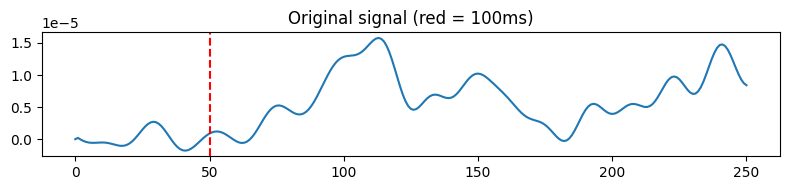

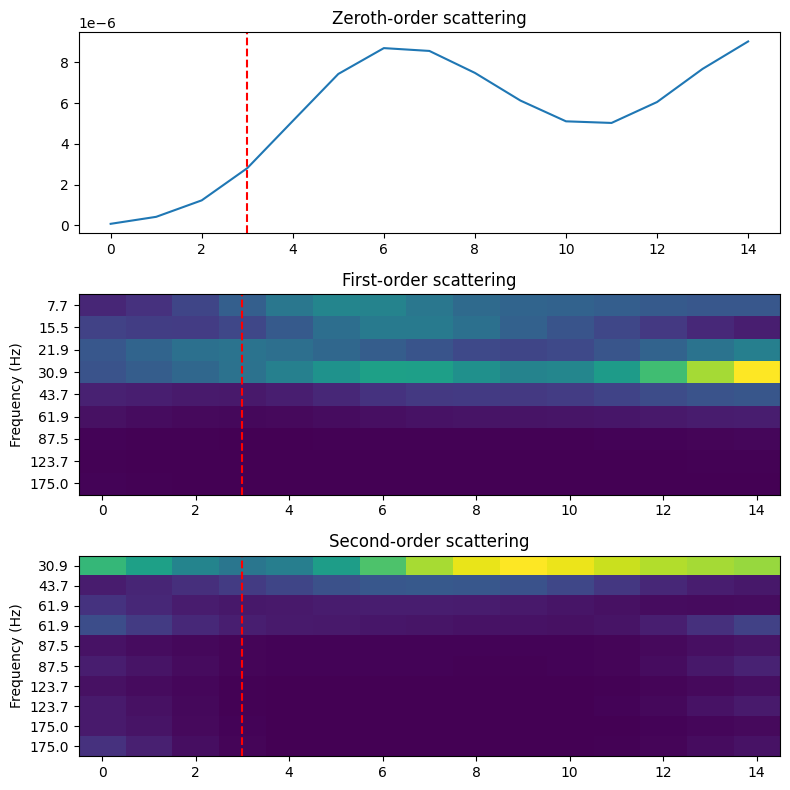

In [91]:
from kymatio.numpy import Scattering1D
import matplotlib.pyplot as plt
import numpy as np


data = data[:-1]  # Remove the last element to match the length of the signal
data = np.insert(data, 0, 0)  # Add a zero before the first element

# Parameters
J = 4  # Number of scales 2**4 -» 16 data points
T = len(data)  # Length of the signal
Q = 2  # Wavelets per octave
sampling_rate = 500  # Hz
event_time_ms = 101  # Time of event in milliseconds
event_sample = int(event_time_ms * sampling_rate / 1000)  # = 50

# Compute scattering
scattering = Scattering1D(J, T, Q)
Sx = scattering(data)
meta = scattering.meta()

# Orders
order0 = np.where(meta['order'] == 0)
order1 = np.where(meta['order'] == 1)
order2 = np.where(meta['order'] == 2)

# Calculate time subsampling factor
subsampling_factor = T // Sx.shape[-1]
event_index_scattering = event_sample // subsampling_factor

# Get frequencies for order-1 and order-2 filters
frequencies_order2 = meta['xi'][order2] * sampling_rate

# Plot original signal
plt.figure(figsize=(8, 2))
plt.plot(data)
plt.axvline(event_sample, color='red', linestyle='--')
plt.title('Original signal (red = 100ms)')
plt.tight_layout()
plt.show()




# Plot scattering coefficients
plt.figure(figsize=(8, 8))

# 0th order scattering
#---------------------------------------------------#
plt.subplot(3, 1, 1)
plt.plot(Sx[order0][0])
plt.axvline(event_index_scattering, color='red', linestyle='--')
plt.title('Zeroth-order scattering')




# 1st order scattering
#---------------------------------------------------#
plt.subplot(3, 1, 2)
plt.imshow(Sx[order1], aspect='auto', origin='lower')
plt.axvline(event_index_scattering, color='red', linestyle='--', )
plt.title('First-order scattering')

frequencies_order1 = meta['xi'][order1][:, 0] * sampling_rate
yticks_pos = np.arange(len(frequencies_order1))  # positions along y-axis
yticks_labels = [f"{freq:.1f}" for freq in frequencies_order1]  # frequency labels in Hz

plt.yticks(yticks_pos, yticks_labels)
plt.ylabel('Frequency (Hz)')




# 2nd order scattering
#---------------------------------------------------#
plt.subplot(3, 1, 3)
plt.imshow(Sx[order2], aspect='auto', origin='lower')
plt.axvline(event_index_scattering, color='red', linestyle='--')
plt.title('Second-order scattering')

frequencies_order2 = meta['xi'][order2][:, 0] * sampling_rate
yticks_pos = np.arange(len(frequencies_order2))  # positions along y-axis
yticks_labels = [f"{freq:.1f}" for freq in frequencies_order2]  # frequency labels in Hz

plt.yticks(yticks_pos, yticks_labels)
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()


In [ ]:
Sx_12 = Sx[..., 1:, :]
print(Sx.shape)
print(Sx_12.shape)

Sx = Sx.globalaver

(20, 15)
(19, 15)


for comparison, CWT

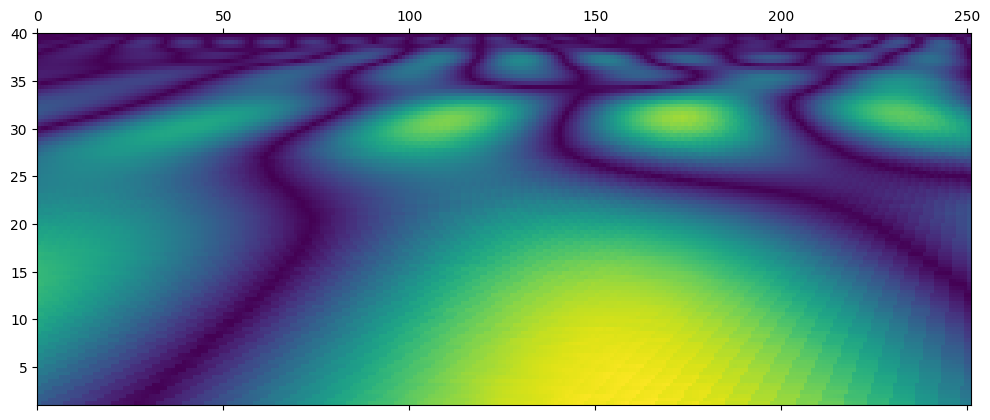

In [48]:
import pywt

def freq_to_scale(freq, wavelet, dt):
    """Convert frequency to scale."""
    central_freq = pywt.central_frequency(wavelet)
    return central_freq / (freq * dt)

# Desired frequency range
f_min, f_max = 1, 40  # Hz

# Convert to corresponding scales
scale_min = freq_to_scale(f_max, 'morl', 1/500)
scale_max = freq_to_scale(f_min, 'morl', 1/500)
scales = np.linspace(scale_min, scale_max, 100)


fs = 500  # Sampling frequency

coef, freqs=pywt.cwt(data, scales,'morl', sampling_period=1/fs)
plt.matshow(np.abs(coef), aspect='auto', extent=[0, len(data), freqs[-1], freqs[0]])

# Machine Learning

## Imports

In [17]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.model_selection import RandomizedSearchCV

## Custom Function

In [ ]:
# Vanilla classifiers out of the box code
dict_classifiers = {
    "Random Forest": RandomForestClassifier(random_state=Random_Seed_State),
    "Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=Random_Seed_State),
    "Neural Net": MLPClassifier(alpha = 1,random_state=Random_Seed_State),
    "Linear SVM": SVC(random_state=Random_Seed_State),
    "Naive Bayes": GaussianNB(),   
    # "AdaBoost": AdaBoostClassifier(random_state=Random_Seed_State),
    # "Gaussian Process": GaussianProcessClassifier(random_state=Random_Seed_State)
    # "Logistic Regression": LogisticRegression(solver='saga',random_state=Random_Seed_State),
    # "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=Random_Seed_State),
}

def batch_classify(X_train, Y_train, X_test, Y_test, no_classifiers = 5, verbose = True):
    dict_models = {}
    for classifier_name, classifier in list(dict_classifiers.items())[:no_classifiers]:
        t_start = time.perf_counter()
        classifier.fit(X_train, Y_train)
        t_end = time.perf_counter()
        t_diff = t_end - t_start
        train_score = classifier.score(X_train, Y_train)
        test_score = classifier.score(X_test, Y_test)
        dict_models[classifier_name] = {'model': classifier, 'train_score': train_score, 'test_score': test_score, 'train_time': t_diff}
        if verbose:
            print("trained {c} in {f:.2f} s".format(c=classifier_name, f=t_diff))
    return dict_models

# Display results in table format
def display_dict_models(dict_models, sort_by='test_score'):
    cls = [key for key in dict_models.keys()]
    test_s = [dict_models[key]['test_score'] for key in cls]
    training_s = [dict_models[key]['train_score'] for key in cls]
    training_t = [dict_models[key]['train_time'] for key in cls]
    
    df_ = pd.DataFrame(data=np.zeros(shape=(len(cls),4)), columns = ['classifier', 'train_score', 'test_score', 'train_time'])
    for ii in range(0,len(cls)):
        df_.loc[ii, 'classifier'] = cls[ii]
        df_.loc[ii, 'train_score'] = training_s[ii]
        df_.loc[ii, 'test_score'] = test_s[ii]
        df_.loc[ii, 'train_time'] = training_t[ii]
    display(df_.sort_values(by=sort_by, ascending=False))

## Train Test split

In [22]:
Channels_of_interest = ['PO7',
                        'PO3',
                        'O1',
                        'POz',
                        'Oz',
                        'PO4',
                        'O2',
                        'PO8',
                       ]

Data = []
Shape = (len(Condition1Epochs_list[0]) * len(Condition1Epochs_list))
Labels = np.array((np.ones(Shape)*0,np.ones(Shape)*1,np.ones(Shape)*2,np.ones(Shape)*3)).flatten()
for condition in [Condition1Epochs_list, Condition2Epochs_list, Condition3Epochs_list, Condition4Epochs_list]:
    for participant in range(len(Condition1Epochs_list)):
        Selected_Channels = []
        Loaded_data = condition[participant].get_data()
        Loaded_data = np.array(Loaded_data)
        for my_picks in Channels_of_interest:
            Channel_Index = Condition1Epochs_list[0].info['ch_names'].index(my_picks)
            Selected_Channels.append(Loaded_data[:,Channel_Index,:])
        Data.append(np.reshape(Selected_Channels,(len(Condition1Epochs_list[0]),len(Channels_of_interest),251)))
Data = np.reshape(Data,(Shape*4,len(Channels_of_interest),251))

Train_size = .8
Test_size = .2
x_train, x_test, y_train, y_test = train_test_split(Data, Labels,train_size = Train_size, test_size = Test_size, random_state = Random_Seed_State, stratify= Labels )
print('Number of training data:', len(x_train),'  ', 'Number of test data:', len(x_test))

IndexError: list index out of range

## ML testing

In [18]:
X_train = np.reshape(x_train,(len(x_train),len(Channels_of_interest)*251))
X_test = np.reshape(x_test,(len(x_test),len(Channels_of_interest)*251))
models = batch_classify(X_train, y_train, X_test, y_test, no_classifiers = 6)
display_dict_models(models)

trained Random Forest in 0.48 s
trained Nearest Neighbors in 0.00 s
trained Decision Tree in 0.25 s
trained Neural Net in 1.49 s
trained Linear SVM in 0.21 s
trained Naive Bayes in 0.01 s


C:\Users\damie\AppData\Local\Temp\ipykernel_154516\29665231.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Random Forest' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_.loc[ii, 'classifier'] = cls[ii]


,classifier,train_score,test_score,train_time
0,Random Forest,1.000000,0.979167,0.483664
1,Nearest Neighbors,0.997396,0.979167,0.001012
4,Linear SVM,1.000000,0.968750,0.213060
5,Naive Bayes,0.901042,0.864583,0.006056
2,Decision Tree,1.000000,0.614583,0.251231
3,Neural Net,0.250000,0.250000,1.487675
